In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
Training_data = pd.read_csv("C:/Users/Ecce H/Team_project/Disease_Prediction_With_ML/data/raw/Training.csv")

In [5]:
#informations about the dataset
Training_data.head()
Training_data.shape
Training_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 134 entries, itching to Unnamed: 133
dtypes: float64(1), int64(132), str(1)
memory usage: 5.0 MB


The dataset contains 4920 observations (rows), each representing a patient record.
There are 134 columns, including 132 symptom features, one target variable (prognosis), and one extra column that was later removed (originally an index column from the CSV).
The symptom features are binary (0 = absence, 1 = presence) indicating whether each symptom is observed for a patient.
The target variable prognosis is categorical with 41 unique disease classes.

In [6]:
#Type of data
print(Training_data.dtypes)

itching                   int64
skin_rash                 int64
nodal_skin_eruptions      int64
continuous_sneezing       int64
shivering                 int64
                         ...   
blister                   int64
red_sore_around_nose      int64
yellow_crust_ooze         int64
prognosis                   str
Unnamed: 133            float64
Length: 134, dtype: object


In [8]:
# dataset  columns names
print(Training_data.columns)

Index(['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing',
       'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity',
       'ulcers_on_tongue',
       ...
       'scurring', 'skin_peeling', 'silver_like_dusting',
       'small_dents_in_nails', 'inflammatory_nails', 'blister',
       'red_sore_around_nose', 'yellow_crust_ooze', 'prognosis',
       'Unnamed: 133'],
      dtype='str', length=134)


In [9]:
# 5 first row of the dataset
Training_data.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [10]:
# Drop the unnamed column"Unnamed:133"
Training_data = Training_data.drop(columns=['Unnamed: 133'])

In [11]:
#check
Training_data.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [12]:
# Checking missing values
missing = Training_data.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

It shows that we have no missing values as the Unnamed 133 column had been dropped

In [13]:
# Checking for duplicates
Training_data.duplicated().sum()

np.int64(4616)

That's mean that we have 4616 duplicates and so only (4920-4616 = 304)304 are unique row

In [14]:
#  'prognosis' is the variable Y
X = Training_data.drop(columns=['prognosis'])
y = Training_data['prognosis']   # variable (keep separately)

In [15]:
#Description of X
X.describe()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
count,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,...,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000
mean,0.137805,0.159756,0.021951,0.045122,0.021951,0.162195,0.139024,0.045122,0.045122,0.021951,...,0.021951,0.021951,0.021951,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171
std,0.344730,0.366417,0.146539,0.207593,0.146539,0.368667,0.346007,0.207593,0.207593,0.146539,...,0.146539,0.146539,0.146539,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Variable description
Training_data['prognosis'].value_counts()

prognosis
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B                                120
Hep

<Axes: xlabel='prognosis'>

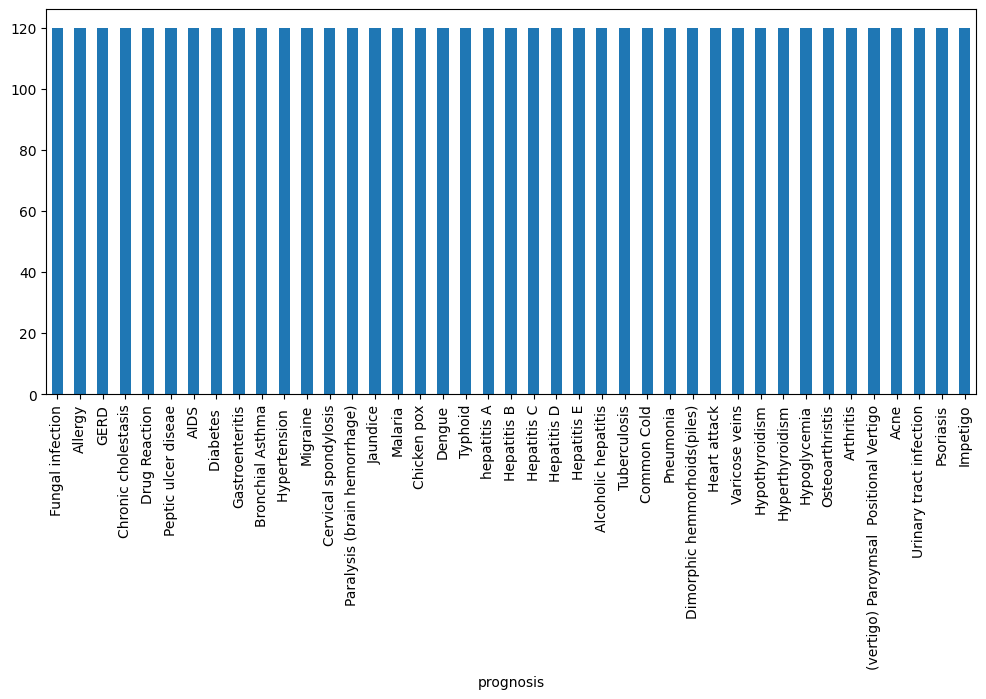

In [17]:
# Checking class balance
Training_data['prognosis'].value_counts().plot(kind='bar', figsize=(12,5))

We notice that all the class are balanced.

In [18]:
# Symptom distribution
symptom_counts = Training_data.iloc[:, :-1].sum().sort_values(ascending=False)
symptom_counts.head(10)

fatigue              1932
vomiting             1914
high_fever           1362
loss_of_appetite     1152
nausea               1146
headache             1134
abdominal_pain       1032
yellowish_skin        912
yellowing_of_eyes     816
chills                798
dtype: int64

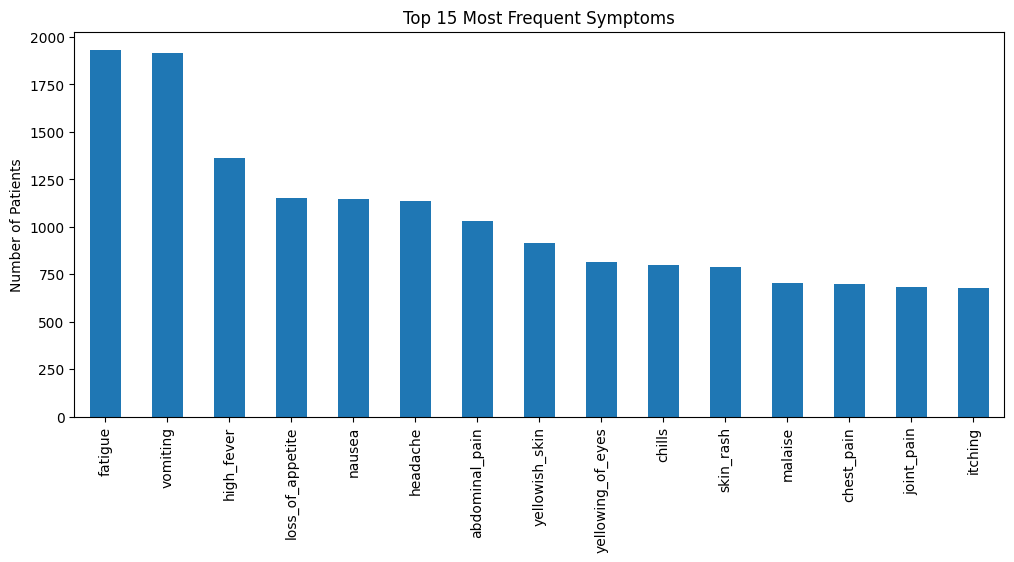

In [19]:
import matplotlib.pyplot as plt

symptom_counts.head(15).plot(kind='bar', figsize=(12,5))
plt.title("Top 15 Most Frequent Symptoms")
plt.ylabel("Number of Patients")
plt.show()

We observe that fatigue, vomiting, high_fever, loss_of_appetite, nausea, headache, abdominal_pain, yellowish_skin, yellowing_of_eyes, chills, skin_rash, malaise, chest_pain, joint_pain, itching are the 15th most frequent symptoms.

In [21]:
# How many symptoms per patient
Training_data['total_symptoms'] = Training_data.iloc[:, :-1].sum(axis=1)

Training_data['total_symptoms'].describe()

C:\Users\Ecce H\AppData\Local\Temp\ipykernel_10540\1535061560.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Training_data['total_symptoms'] = Training_data.iloc[:, :-1].sum(axis=1)


count    4920.000000
mean        7.448780
std         3.592166
min         3.000000
25%         5.000000
50%         6.000000
75%        10.000000
max        17.000000
Name: total_symptoms, dtype: float64

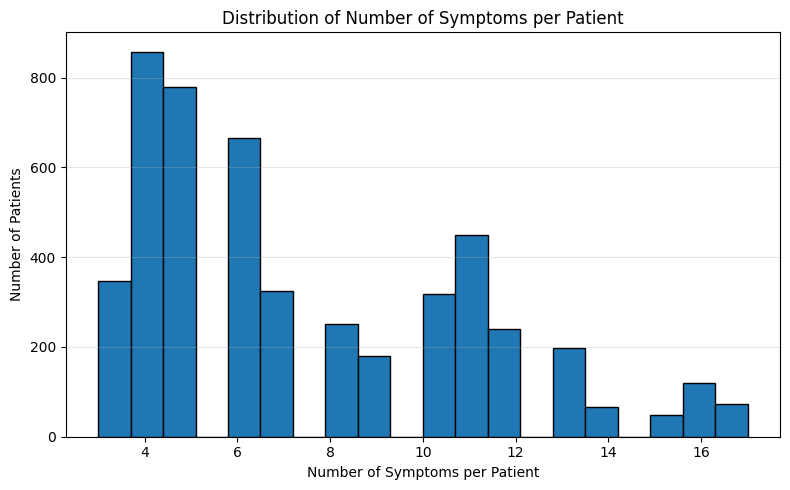

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(Training_data['total_symptoms'], bins=20, edgecolor='black')

plt.title("Distribution of Number of Symptoms per Patient")
plt.xlabel("Number of Symptoms per Patient")   # X-axis label
plt.ylabel("Number of Patients")               # Y-axis label

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The histogram shows a positively skewed distribution of symptom counts per patient. Most individuals report between 3 and 6 symptoms, with fewer cases exhibiting a high symptom burden (>14 symptoms). This suggests moderate variability in symptom presentation across patients.

In [24]:
#Compare symptom count by disease
#  Group by disease and calculate mean, median, and count of symptoms
symptom_stats = Training_data.groupby('prognosis')['total_symptoms'].agg(['mean', 'median', 'count']).sort_values(by='mean')

print(symptom_stats.head(10))  # Top 10 diseases with lowest avg symptoms
print(symptom_stats.tail(10))  # Top 10 diseases with highest avg symptoms

                              mean  median  count
prognosis                                        
Allergy                       3.60     4.0    120
Fungal infection              3.60     4.0    120
Acne                          3.65     4.0    120
AIDS                          3.65     4.0    120
Heart attack                  3.65     4.0    120
Gastroenteritis               3.65     4.0    120
Urinary tract infection       3.65     4.0    120
Paralysis (brain hemorrhage)  3.65     4.0    120
Drug Reaction                 4.55     5.0    120
Hypertension                  4.60     5.0    120
                  mean  median  count
prognosis                            
Hyperthyroidism  10.60    11.0    120
Typhoid          10.60    11.0    120
hepatitis A      10.60    11.0    120
Hepatitis B      11.60    12.0    120
Hypoglycemia     11.60    12.0    120
Hypothyroidism   12.60    13.0    120
Hepatitis E      12.60    13.0    120
Dengue           13.55    14.0    120
Tuberculosis     15.

Diseases with Low Average Symptoms (~3.6–4.6)

Examples: Allergy, Fungal infection, Acne, AIDS, Heart attack, Urinary tract infection

These tend to have fewer symptoms per patient—possibly more specific or less complex presentations.

Diseases with High Average Symptoms (~10.6–16.6)

Examples: Hyperthyroidism, Typhoid, Hepatitis types, Dengue, Tuberculosis, Common Cold

These show a much higher symptom burden, indicating more complex or multi-symptom presentations.

Consistency in Counts

Each disease has exactly 120 patients — so this dataset is well balanced by disease class.

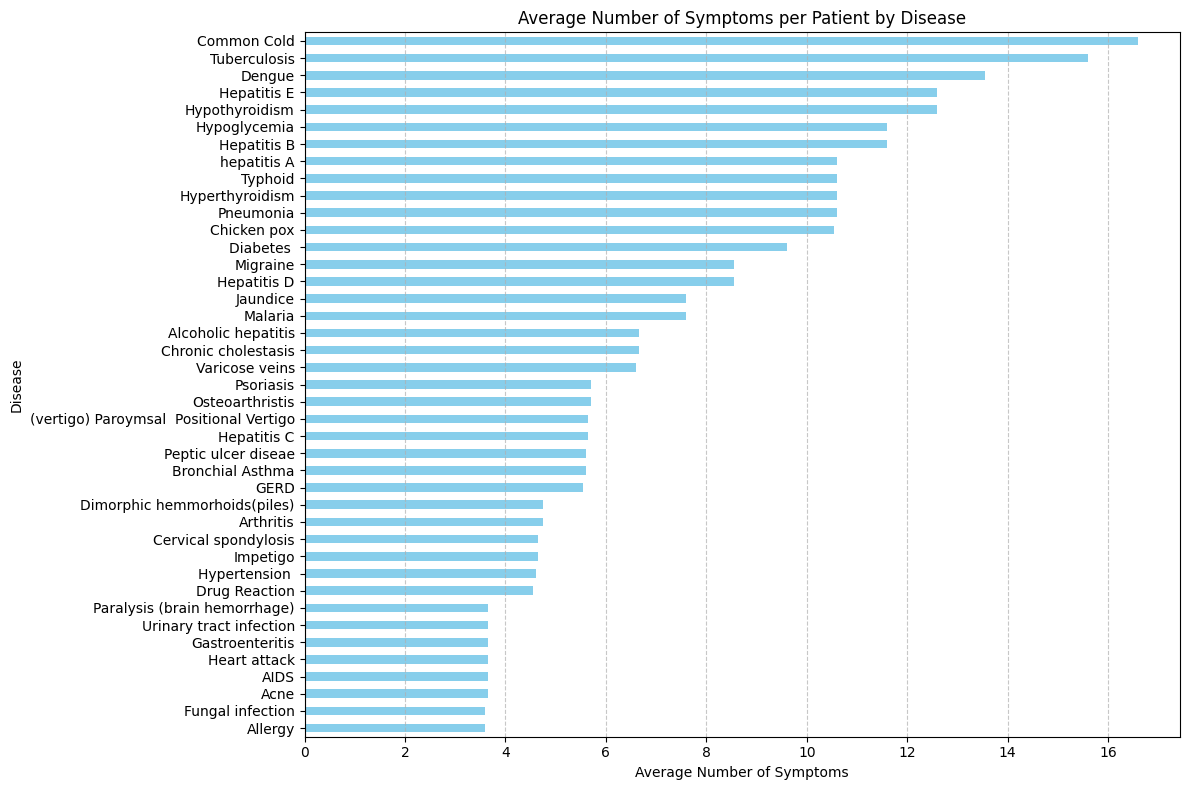

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
symptom_stats['mean'].plot(kind='barh', color='skyblue')
plt.xlabel('Average Number of Symptoms')
plt.ylabel('Disease')
plt.title('Average Number of Symptoms per Patient by Disease')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [32]:
import numpy as np
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# --- Set seed for reproducibility ---
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# --- Features and target ---
# Assume df is already loaded
X = Training_data.iloc[:, 1:-2]  # all symptom columns (exclude patient_id if present and prognosis)
le = LabelEncoder()
y = le.fit_transform(Training_data['prognosis'])

# --- Train-test split (stratified for balanced classes) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# --- Save disease labels for later ---
disease_classes = le.classes_

print("Data preparation complete.")
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Data preparation complete.
Training samples: 3936, Test samples: 984


In [33]:
X_train

,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,muscle_wasting,...,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
3374,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1432,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3663,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3296,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3232,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2608,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2160,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1449,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
y_train

array([ 7, 19, 28, ..., 30, 20,  2], shape=(3936,))

In [35]:
# Model 1: Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=disease_classes))
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

Random Forest Classification Report:

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                            Common Cold       1.00      1.00      1.00

Random Forest achieved perfect classification performance on the dataset, indicating that diseases in this dataset have uniquely distinguishable symptom profiles. However, this likely reflects the structured and noise-free nature of the dataset rather than real-world clinical variability.

Top 20 Most Important Symptoms (Random Forest):
muscle_pain              0.018801
family_history           0.015814
fatigue                  0.015640
mild_fever               0.015420
yellowing_of_eyes        0.014857
joint_pain               0.014293
lack_of_concentration    0.013721
vomiting                 0.013451
dark_urine               0.013359
mucoid_sputum            0.013271
sweating                 0.013010
nausea                   0.012893
unsteadiness             0.012475
chest_pain               0.012377
neck_pain                0.012264
stomach_bleeding         0.012130
internal_itching         0.011584
dehydration              0.011570
altered_sensorium        0.011365
weight_loss              0.011236
dtype: float64


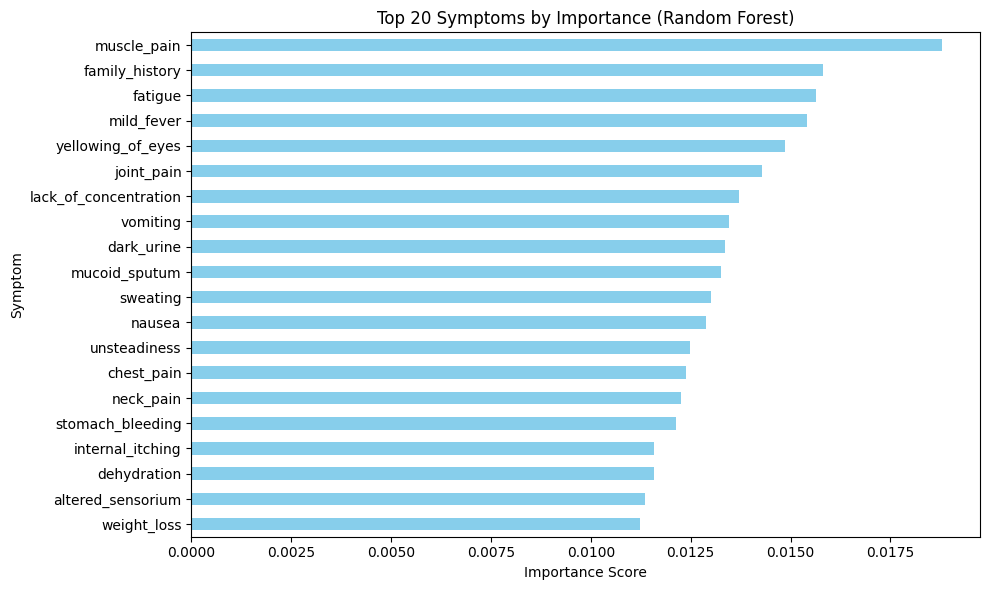

In [37]:
import pandas as pd

# Get feature importance
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)

# Sort descending and show top 20
top20_rf = feature_importances.sort_values(ascending=False).head(20)
print("Top 20 Most Important Symptoms (Random Forest):")
print(top20_rf)

# Optional: visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
top20_rf.plot(kind='barh', color='skyblue')
plt.xlabel('Importance Score')
plt.ylabel('Symptom')
plt.title('Top 20 Symptoms by Importance (Random Forest)')
plt.gca().invert_yaxis()  # highest importance on top
plt.tight_layout()
plt.show()

In [36]:
# Model2 : Bernoulli Naives
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB()
bnb.fit(X_train, y_train)

y_pred_bnb = bnb.predict(X_test)

print("Bernoulli Naive Bayes Classification Report:\n")
print(classification_report(y_test, y_pred_bnb, target_names=disease_classes))
print(f"BernoulliNB Accuracy: {accuracy_score(y_test, y_pred_bnb):.4f}")

Bernoulli Naive Bayes Classification Report:

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                            Common Cold       1.00      1.00  

Bernoulli Naive Bayes achieved perfect classification performance (100% accuracy, precision, recall, and F1-score). This indicates that individual symptom presence probabilities are sufficient to uniquely distinguish all diseases in the dataset. The independence assumption of Naive Bayes does not degrade performance, suggesting that diseases are structurally separable based on symptom patterns alone. While the results demonstrate strong predictive capability within this dataset, the perfect performance likely reflects the dataset’s deterministic and noise-free structure. Real-world clinical data typically involve overlapping symptoms and reporting variability, which would reduce classification performance.

| Metric                | Bernoulli Naive Bayes    | Random Forest              | Interpretation                                |
| --------------------- | ------------------------ | -------------------------- | --------------------------------------------- |
| Accuracy              | 1.00                     | 1.00                       | Both models perfectly classify all diseases   |
| Precision (Macro Avg) | 1.00                     | 1.00                       | No false positives in either model            |
| Recall (Macro Avg)    | 1.00                     | 1.00                       | No false negatives in either model            |
| F1-Score (Macro Avg)  | 1.00                     | 1.00                       | Perfect balance of precision and recall       |
| Model Complexity      | Low                      | Moderate                   | Random Forest is more computationally complex |
| Assumptions           | Conditional independence | No independence assumption | NB assumes independent symptoms               |


Both Bernoulli Naive Bayes and Random Forest achieved identical perfect performance across all evaluation metrics.

This result suggests:

The diseases in the dataset are completely separable based on symptom presence.

The independence assumption in Naive Bayes does not negatively impact predictive performance.

Modeling complex non-linear interactions (as done by Random Forest) does not improve classification accuracy.

The fact that a simple probabilistic model performs as well as an ensemble tree-based method indicates that the decision boundary between diseases is structurally clear and deterministic.

In typical real-world datasets, Random Forest would be expected to outperform Naive Bayes due to its ability to model interactions between features. However, in this dataset, symptom combinations are already sufficiently distinctive to allow perfect classification without modeling interactions.
In real clinical settings:

- Symptoms overlap across diseases

- Patients may report symptoms inaccurately

- Data contains noise and missing values

Therefore, while the models demonstrate strong predictive capability within this dataset, their real-world performance would likely be lower.

The identical performance of both models suggests that the dataset behaves more like a deterministic rule-based system rather than complex medical data.